In [1]:
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import matplotlib as mpl
import xml.etree.ElementTree as ET
import shapely
import cartopy
import pyproj
import numpy
from math import sin,cos,radians
from pathlib import Path
from datetime import datetime

In [2]:
title = "Seduisant WNR Series 2 4/29/2026"
outfileBase = "Seduisant WNR Series 2 2026-04-29"
outputPath = "./output/Seduisant"

waypointFile = "./tracks/2020LakePontchartrainRacingMarks.gpx"
trackFile = "./tracks/Track_2026-04-29 195652.gpx"
windFile = "./windData/burl1_2026-04-30.pickle"
proj = cartopy.crs.Mercator()
buffer = 0.25 / 60 #buffer in nautical miles
figsize = (25,8)
nm2Meter = 1852.0
colorMap = mpl.cm.magma

In [3]:
wgs84 = pyproj.crs.CRS.from_string('WGS84')
utm = pyproj.crs.CRS.from_string('EPSG:32615')

In [4]:
Path(outputPath).mkdir(exist_ok=True,parents=True)

In [5]:
waypointXML = ET.parse(waypointFile)

In [ ]:
wptList = []
for child in waypointXML.getroot():
    data = {
                'name':child.find('{http://www.topografix.com/GPX/1/1}name').text,
                'geometry':shapely.Point(child.attrib['lon'],child.attrib['lat'])
    }
    
    wptList.append(data)

waypointGdf = gpd.GeoDataFrame(data= pd.DataFrame.from_dict(wptList), geometry='geometry', crs=wgs84)

In [ ]:
waypointGdf.drop_duplicates(subset=['name'], inplace=True)

In [ ]:
waypointGdf['name'] = waypointGdf['name'].str.replace('"','').str.replace('SYC ','')

In [ ]:
waypointGdf.set_index('name', inplace=True)

In [ ]:
trkXML = ET.parse(trackFile)

In [ ]:
trkSegXML = trkXML.getroot().find('{http://www.topografix.com/GPX/1/1}trk').\
    find('{http://www.topografix.com/GPX/1/1}trkseg')

In [ ]:
trkList = []
for child in trkSegXML:
    data = {
                'time':child.find('{http://www.topografix.com/GPX/1/1}time').text,
                'geometry':shapely.Point(child.attrib['lon'],child.attrib['lat'])
           }
    
    trkList.append(data)

trkGdf = gpd.GeoDataFrame(data=pd.DataFrame.from_dict(trkList), geometry='geometry', crs=wgs84)

In [ ]:
trkGdf['time'] = pd.to_datetime( trkGdf['time'] ).dt.tz_convert('US/Central')
print(f"Start time {trkGdf['time'].min()}")

In [ ]:
trkGdf['timeDelta'] = trkGdf['time'] - trkGdf['time'].shift(1)
trkGdf['timeCumsum'] = trkGdf['timeDelta'].cumsum()
print(f"Mean time between measure {trkGdf['timeDelta'].mean()}")

In [ ]:
geod = pyproj.Geod(ellps='clrk66')
print(f"Total distance {geod.line_length(trkGdf['geometry'].x, trkGdf['geometry'].y) / nm2Meter}nm")

In [ ]:
trkGdf['bearing'] = geod.inv(trkGdf['geometry'].x,trkGdf['geometry'].y, trkGdf['geometry'].shift(1).x, trkGdf['geometry'].shift(1).y)[1]

In [ ]:
mask = trkGdf['bearing'] < 0
trkGdf.loc[mask, 'bearing'] = trkGdf['bearing'][mask] + 360.0

In [ ]:
trkGdf['delta_distance'] = numpy.nan
trkGdf.loc[1:,'delta_distance'] = geod.line_lengths(trkGdf['geometry'].x, trkGdf['geometry'].y) / nm2Meter

In [ ]:
trkGdf['dist_cumsum'] = trkGdf['delta_distance'].cumsum()

In [ ]:
trkGdf['delta_distance'].sum()

In [ ]:
trkGdf['speed'] = (60.0 * 60.0 * trkGdf['delta_distance']) / trkGdf['timeDelta'].dt.total_seconds()

In [ ]:
print(f"speed max:{trkGdf['speed'].max()}\tmin:{trkGdf['speed'].min()}\tmean:{trkGdf['speed'].mean()}")

In [ ]:
trkGdf.set_index('time',inplace=True)

In [ ]:
trkGdf = trkGdf[numpy.logical_and( trkGdf.index>'2026-04-29 19:10:00-05:00',\
                                   trkGdf.index<'2026-04-29 19:43:00-05:00')].copy()

In [ ]:
dirArrowTimes = pd.date_range(start=trkGdf.index[0], end=trkGdf.index[-1], periods=5)[1:]

In [ ]:
trkGdf.head()

In [ ]:
windDf = pd.read_pickle(windFile)
mask = numpy.logical_and( (windDf.index >= trkGdf.index.min()),\
                        windDf.index <= trkGdf.index.max())
windDf = windDf[mask].copy()
medianWind = windDf['WDIR'].median()
meanWindSpeed = windDf['WSPD'].mean()
print(f"Median wind direction: {medianWind}")
print(f"Mean wind speed:  {meanWindSpeed}")
windDf.head()

In [ ]:
def createWindQuiver(ax):
    
    arrowRows = 20
    axExtent = ax.get_extent()
    lonMin = axExtent[0]
    lonMax = axExtent[1]
    lonRange = numpy.arange(lonMin,lonMax, (lonMax-lonMin)/arrowRows)
    latMin = axExtent[2]
    latMax = axExtent[3]
    latRange = numpy.arange(latMin,latMax, (latMax-latMin)/arrowRows)
    
    (lonMesh,latMesh) = numpy.meshgrid(lonRange, latRange)
    ax.quiver(x=lonMesh,y=latMesh,\
              u=sin(radians(medianWind+180)),v=cos(radians(medianWind+180)),\
              angles='uv',\
              color =(0,0,0,0.2),
              zorder=-2,
              label=f"Wind Dir {medianWind:.0f}\U000000B0")


In [ ]:
trkGdf['geometry'].asof(dirArrowTimes[0])

In [ ]:
def createPlot(ax, extent, s=72, wpS=500,plotWind=True, lblWpt=True ,extentBuffer=buffer, df=trkGdf):
    
    boundBox = shapely.geometry.box(*extent)
    wptMask = waypointGdf['geometry'].map(lambda pt: boundBox.contains(pt))
    
    tmDelta = pd.Timedelta('1 minute')
    for tm in dirArrowTimes:
        pt1 = df['geometry'].asof(tm)
        pt2 = df['geometry'].asof(tm+tmDelta)
        arrowBuffer = 0.001
        arrow = mpl.patches.FancyArrowPatch( (pt1.x, pt1.y+arrowBuffer), (pt2.x, pt2.y+arrowBuffer) ,mutation_scale=20, zorder=-1      )
        ax.add_patch(arrow)
    
    
    ax.scatter(waypointGdf.geometry.x, waypointGdf.geometry.y, marker='s',s=wpS, c='r', label='Marker')

    if lblWpt:
        for idx,item in waypointGdf[wptMask].iterrows():
            ax.text(item['geometry'].x,item['geometry'].y,idx, va='center', ha='center', fontsize='20', fontname='serif',c='b' )
    
    ax.set_xlim(extent[0]-extentBuffer, extent[2]+extentBuffer)
    ax.set_ylim(extent[1]-extentBuffer, extent[3]+extentBuffer)
    ax.coastlines()
    
    
    trkPlt = ax.scatter(df.geometry.x,df.geometry.y, c=colorMap(norm(df['speed'])), s=s)
    
    if plotWind:
        createWindQuiver(ax)

    


In [ ]:
fig,ax = plt.subplots(1, figsize=figsize ,subplot_kw={'projection': proj})

norm = mpl.colors.Normalize(vmin=trkGdf['speed'].min(), vmax = trkGdf['speed'].max(), clip=True)
colorbarTicks = numpy.arange(norm.vmin,norm.vmax+0.001,1.0)

cax = fig.colorbar( plt.cm.ScalarMappable(norm=norm, cmap=colorMap), ax=ax)   
cax.set_ticks(colorbarTicks)
cax.set_ticklabels( [f"{int(i)}kn" for i in colorbarTicks])

createPlot(ax,s=20, extent=trkGdf.total_bounds)




wptRadius = 0.1 / 60
jExtent = waypointGdf.loc['H','geometry'].buffer(wptRadius).bounds
jInset = ax.inset_axes([0.75,0.10,0.3,0.3], projection=proj, zorder=10 )
createPlot(jInset, jExtent, s=10, wpS=50, plotWind=False, lblWpt=False, extentBuffer=0 )

wptRadius = 0.2 / 60
aExtent = waypointGdf.loc['A','geometry'].buffer(wptRadius).bounds
aInset = ax.inset_axes([0.01,0.25,0.15,0.15], projection=proj, zorder=10 )
createPlot(aInset, aExtent, s=10, wpS=50, plotWind=False, lblWpt=False, extentBuffer=0 )

#add wind speed
windStr = f"""Wind Source:      BURL1
Mean Wind Speed:  {meanWindSpeed:.1f}kn
Median Wind Dir:  {medianWind}\U000000B0"""
ax.text(0.01,0.82,windStr, transform=ax.transAxes,\
        fontsize=20,\
        fontfamily='monospace',\
       bbox={
           'boxstyle':'round',
           'facecolor':'wheat',
           'alpha':0.5
       })

ax.legend()

fig.suptitle(title)
fig.tight_layout()
fig.savefig(f"{outputPath}/{outfileBase}.jpg")
fig.savefig(f"{outputPath}/{outfileBase}.svg")

### Collision

Small collision (no damage) incuring penalty rounding mark H.

The quesiton becomes was the pently in the zone or not?  Find out below

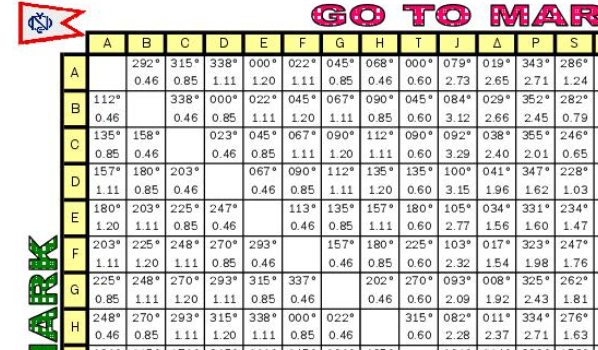

mark bearing 276 this is important as we went hard to port well below of mark to disengage

In [ ]:
trkGdfUTM = trkGdf.to_crs(utm)
waypointGdfUTM = waypointGdf.to_crs(utm)
boatLength = 10.668  #google say its 36.5 feet in but in meters, idk
trkGdfUTM['DistanceFromH'] = trkGdfUTM.distance(waypointGdfUTM.loc['H','geometry'])
trkGdfUTM['DegBellowMark'] = 276 - trkGdfUTM['bearing']

In [ ]:
print(f"{trkGdfUTM['DistanceFromH'].min() / boatLength:.2f} boat lengths from H at closest approach")

In [ ]:
#reverse deltaV since deltaV shows in the point immediatly AFTER collision
trkGdfUTM['DeltaV'] = trkGdfUTM['speed'] - trkGdfUTM['speed'].shift(-1)

In [ ]:
markMask = trkGdfUTM['DistanceFromH'] < (boatLength * 12)
closeMarkMask = trkGdfUTM['DistanceFromH'] < (boatLength * 4)

In [ ]:
colisionTimeStamp = trkGdfUTM[markMask]['DeltaV'].abs().idxmax()

In [ ]:
#tack assumed to begin right before bearing change
trkGdfUTM['DeltaBearing'] = trkGdfUTM['bearing'] - trkGdfUTM['bearing'].shift(1)
tackTime = trkGdfUTM.loc[markMask,'DeltaBearing'].abs().idxmax()

In [ ]:
#must be max below mark, very close to mark because know it was and point before we turn
#as we turned down to disengage after collision we must also be slowing down

bearingMask = (trkGdfUTM.index >tackTime) & closeMarkMask
collisionTimeStamp_Bearing = trkGdfUTM[bearingMask]['DeltaBearing'].idxmin()

In [ ]:
def createPlotUTM(ax, extent, s=72, wpS=500,plotWind=True, lblWpt=True ,extentBuffer=buffer, df=trkGdfUTM):
    
    boundBox = shapely.geometry.box(*extent)
    wptMask = waypointGdfUTM['geometry'].map(lambda pt: boundBox.contains(pt))

    dirArrowTimesUTM = pd.date_range(start=trkGdfUTM[markMask].index[0]\
                                     , end=trkGdfUTM[markMask].index[-1], periods=15)[1:]

    
    
    ax.scatter(waypointGdfUTM.geometry.x, waypointGdfUTM.geometry.y, marker='s',s=wpS, c='r', label='Marker H')

    if lblWpt:
        for idx,item in waypointGdfUTM[wptMask].iterrows():
            ax.text(item['geometry'].x,item['geometry'].y,idx, va='center', ha='center', fontsize='20', fontname='serif',c='b' )
    
    ax.set_xlim(extent[0]-extentBuffer, extent[2]+extentBuffer)
    ax.set_ylim(extent[1]-extentBuffer, extent[3]+extentBuffer)
    ax.coastlines()
    
    
    trkPlt = ax.scatter(df.geometry.x,df.geometry.y, c=colorMapUTM(normUTM(df['DistanceFromH'])), s=s)
    
    if plotWind:
        createWindQuiver(ax)

    


In [ ]:
fig,ax = plt.subplots(1, figsize=(17,10) ,subplot_kw={'projection': proj})

#normUTM = mpl.colors.Normalize(vmin=0, vmax = trkGdfUTM[markMask]['DistanceFromH'].max(), clip=True)
normUTM = mpl.colors.TwoSlopeNorm(boatLength*3, vmin=0, vmax = trkGdfUTM[markMask]['DistanceFromH'].max())
colorbarTicks = numpy.arange(normUTM.vmin,normUTM.vmax+0.001,boatLength)

colorMapUTM = mpl.cm.seismic_r
cax = fig.colorbar( plt.cm.ScalarMappable(norm=normUTM, cmap=colorMapUTM), ax=ax)
    
cax.set_ticks(colorbarTicks)
cax.set_ticklabels( [f"{int(i)} m" for i in colorbarTicks])
cax.set_label("Distance from Mark H")

createPlotUTM(ax,s=50, extent=trkGdfUTM[markMask].total_bounds, extentBuffer=boatLength)

ax.plot(trkGdfUTM[markMask]['geometry'].x,trkGdfUTM[markMask]['geometry'].y, label='Course', zorder=-1,c=(0,0,1,0.4),linestyle='--')

markRadius = mpl.patches.Circle([i[0] for i in waypointGdfUTM.loc['H','geometry'].xy],\
                               radius=boatLength*3,\
                               fill=False,\
                               label='Mark Zone',\
                               linestyle='--',\
                                color='grey',\
                                zorder=-5)
ax.add_patch(markRadius)

collisionPt = trkGdfUTM.loc[colisionTimeStamp,'geometry']
ax.scatter(collisionPt.x,collisionPt.y,\
           zorder=10, color='r', label='Collision By DeltaV',marker='x',s=300)

collisionBearingPt = trkGdfUTM.loc[collisionTimeStamp_Bearing,'geometry']
ax.scatter(collisionBearingPt.x,collisionBearingPt.y,\
           zorder=10, color='b', label='Collision By Bearing',marker='x',s=300)

ax.scatter(trkGdfUTM.loc[tackTime,'geometry'].x,trkGdfUTM.loc[tackTime,'geometry'].y,\
           zorder=10, color='g', label='Jibe',marker='x',s=300)


arrowBufferUTM = 5
for idx in [0,12,20,26,30,33]:
    pt1 = trkGdfUTM[markMask].iloc[idx]['geometry']
    pt2 = trkGdfUTM[markMask].iloc[idx+1]['geometry']
    arrow = mpl.patches.FancyArrowPatch( (pt1.x, pt1.y+arrowBufferUTM), (pt2.x, pt2.y+arrowBufferUTM) ,mutation_scale=20, zorder=-1      )
    ax.add_patch(arrow)


collisionText=f"""DeltaV:    {trkGdfUTM.loc[colisionTimeStamp,'DeltaV']:.1f}kn
DistMark:  {trkGdfUTM.loc[colisionTimeStamp,'DistanceFromH']:.0f}m
BoatLen:   {trkGdfUTM.loc[colisionTimeStamp,'DistanceFromH']/boatLength:.2f}
DeltaCrs:  {trkGdfUTM.loc[colisionTimeStamp,'DeltaBearing']:.0f}
BelowMarkS:{trkGdfUTM.loc[colisionTimeStamp,'DegBellowMark']:.0f}\U000000B0"""
ax.text(collisionPt.x-20,collisionPt.y+6,collisionText,\
       fontsize=14,\
        fontfamily='monospace',color='r',\
       bbox={
           'boxstyle':'round',
           'facecolor':'wheat',
           'alpha':0.5
       })

collisionTextBearing=f"""DeltaV:    {trkGdfUTM.loc[collisionTimeStamp_Bearing,'DeltaV']:.1f}kn
DistMark:  {trkGdfUTM.loc[collisionTimeStamp_Bearing,'DistanceFromH']:.0f}m
BoatLen:   {trkGdfUTM.loc[collisionTimeStamp_Bearing,'DistanceFromH']/boatLength:.2f}
DeltaCrs:  {trkGdfUTM.loc[collisionTimeStamp_Bearing,'DeltaBearing']:.0f}
BelowMarkS:{trkGdfUTM.loc[collisionTimeStamp_Bearing,'DegBellowMark']:.0f}\U000000B0"""
ax.text(collisionBearingPt.x-4,collisionBearingPt.y-19,collisionTextBearing,\
       fontsize=14,\
        fontfamily='monospace',color='b',\
       bbox={
           'boxstyle':'round',
           'facecolor':'wheat',
           'alpha':0.5
       })

ax.set_title("Collision Analysis")

ax.legend()
fig.tight_layout()
fig.savefig(f"{outputPath}/{outfileBase} Collision.jpg")
fig.savefig(f"{outputPath}/{outfileBase} Collision.svg")

In [ ]:
print(f"Collision happens {trkGdfUTM.loc[colisionTimeStamp,'DistanceFromH'] / boatLength:0.1f} boat lengdths from mark")

In [ ]:
collisionBoatLenFromTack = trkGdfUTM.loc[tackTime,'geometry'].distance(trkGdfUTM.loc[colisionTimeStamp,'geometry']) /\
                            boatLength
print(f"Collision happens {collisionBoatLenFromTack:0.1f} boat lengths from tack")

In [ ]:
print(datetime.now())